<a href="https://colab.research.google.com/github/tanvisht/Data-Science-NYU-Stern/blob/Assignments/Challenge_7_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 7 - Logistic Regression
**Name:** Tanvish Tuplondhe

**Course:** Data Analytics for Process Improvement
IE-GY 9113 - SPRING 2026

## Problem 1 – Student Application Data

**1. Run a model to predict if a student will apply to university or not.**

**Load and inspect**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# Load dataset directly from GitHub
url = 'https://raw.githubusercontent.com/jcbonilla/BusinessAnalytics/master/BAData/Univ%20Admissions.csv'
df = pd.read_csv(url)

# Initial inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (225015, 10)

Columns: ['x.Country', 'x.State', 'x.Gender', 'x.Source', 'x.GPA', 'x.SAT_Score', 'x.DistancetoCampus_miles', 'x.HouseholdIncome', 'x.Status.1', 'x.InState']

First 5 rows:


,x.Country,x.State,x.Gender,x.Source,x.GPA,x.SAT_Score,x.DistancetoCampus_miles,x.HouseholdIncome,x.Status.1,x.InState
0,USA,NY,Male,NRCCUA-PurchaseNames,2.0,NaN,44.542651,36990.0,SUSPECT,N
1,USA,NY,Male,NRCCUA-PurchaseNames,2.0,NaN,40.501793,33919.0,SUSPECT,N
2,USA,NY,Female,NRCCUA-PurchaseNames,2.0,NaN,211.000192,55624.0,SUSPECT,N
3,USA,FL,Male,NRCCUA-PurchaseNames,2.0,NaN,1013.992587,33105.0,SUSPECT,N
4,USA,NJ,Female,NRCCUA-PurchaseNames,2.0,NaN,59.800086,25999.0,SUSPECT,N


**Explore Target Variable + Preprocessing**

In [3]:
# Explore the target variable and check data quality
print("Target variable 'x.Status.1' distribution:")
print(df['x.Status.1'].value_counts())
print(f"\nPercentage breakdown:")
print(df['x.Status.1'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nUnique values in target: {df['x.Status.1'].unique()}")

Target variable 'x.Status.1' distribution:
x.Status.1
SUSPECT      200379
APPLICANT     12500
PROSPECT      12136
Name: count, dtype: int64

Percentage breakdown:
x.Status.1
SUSPECT      89.05%
APPLICANT     5.56%
PROSPECT      5.39%
Name: proportion, dtype: object

Missing values per column:
x.Country                       77
x.State                         23
x.Gender                     20150
x.Source                         0
x.GPA                       115756
x.SAT_Score                 190176
x.DistancetoCampus_miles       953
x.HouseholdIncome                0
x.Status.1                       0
x.InState                        0
dtype: int64

Unique values in target: ['SUSPECT' 'PROSPECT' 'APPLICANT']


**Preprocessing + Model**

In [4]:
# Create binary target: 1 = APPLICANT, 0 = everything else
df['target'] = (df['x.Status.1'] == 'APPLICANT').astype(int)

print("Binary target distribution:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Drop high-missingness columns (SAT_Score: 84% missing, GPA: 51% missing)
# Keep features with manageable missingness
df_model = df[['x.Country', 'x.State', 'x.Gender', 'x.Source',
               'x.DistancetoCampus_miles', 'x.HouseholdIncome',
               'x.InState', 'target']].copy()

# Drop rows with any remaining missing values
df_model.dropna(inplace=True)
print(f"\nShape after dropping missing values: {df_model.shape}")

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
cat_cols = ['x.Country', 'x.State', 'x.Gender', 'x.Source', 'x.InState']
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print("\nPreprocessing complete. Sample:")
print(df_model.head(3))

Binary target distribution:
target
0    212515
1     12500
Name: count, dtype: int64
target
0    94.44%
1     5.56%
Name: proportion, dtype: object

Shape after dropping missing values: (203859, 8)

Preprocessing complete. Sample:
   x.Country  x.State  x.Gender  x.Source  x.DistancetoCampus_miles  \
0          0       33         1        14                 44.542651   
1          0       33         1        14                 40.501793   
2          0       33         0        14                211.000192   

   x.HouseholdIncome  x.InState  target  
0            36990.0          0       0  
1            33919.0          0       0  
2            55624.0          0       0  


**2. Create an appropriate split and validate your model using the accuracy metric
(ratio of correct predictions vs total predictions).**


**Split + Train Decision Tree**

In [13]:
import numpy as np

float32_max = np.finfo(np.float32).max

# Check the outlier value in HouseholdIncome
print("HouseholdIncome stats:")
print(df_model['x.HouseholdIncome'].describe())
print(f"\nFloat32 max: {float32_max}")
print(f"Values exceeding float32 max: {(df_model['x.HouseholdIncome'] > float32_max).sum()}")

# Cap HouseholdIncome at float32 max (or drop — here we cap it)
df_model['x.HouseholdIncome'] = df_model['x.HouseholdIncome'].clip(upper=float32_max)

# Verify fix
print(f"\nValues exceeding float32 max after fix: {(df_model['x.HouseholdIncome'] > float32_max).sum()}")
print(f"Max HouseholdIncome after fix: {df_model['x.HouseholdIncome'].max()}")
print(f"\nClean dataset shape: {df_model.shape}")

HouseholdIncome stats:
count     2.038530e+05
mean     2.869715e+143
std      1.295679e+146
min       2.003700e+04
25%       5.896100e+04
50%       8.935100e+04
75%       1.162150e+05
max      5.850000e+148
Name: x.HouseholdIncome, dtype: float64

Float32 max: 3.4028234663852886e+38
Values exceeding float32 max: 1

Values exceeding float32 max after fix: 0
Max HouseholdIncome after fix: 3.4028234663852886e+38

Clean dataset shape: (203853, 8)


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Define features and target
X = df_model.drop(columns=['target'])
y = df_model['target']

# Split 70/30 with stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Train decision tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

print(f"\nTree depth:       {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

Training samples: 142697
Test samples:     61156

Class distribution in training set:
target
0    96.9%
1     3.1%
Name: proportion, dtype: object

Tree depth:       4
Number of leaves: 16


**3. Interpret your model.**

Overall Accuracy: 95.07%

Classification Report:
               precision    recall  f1-score   support

Not Applicant       0.99      0.96      0.97     59263
    Applicant       0.34      0.61      0.43      1893

     accuracy                           0.95     61156
    macro avg       0.66      0.79      0.70     61156
 weighted avg       0.97      0.95      0.96     61156



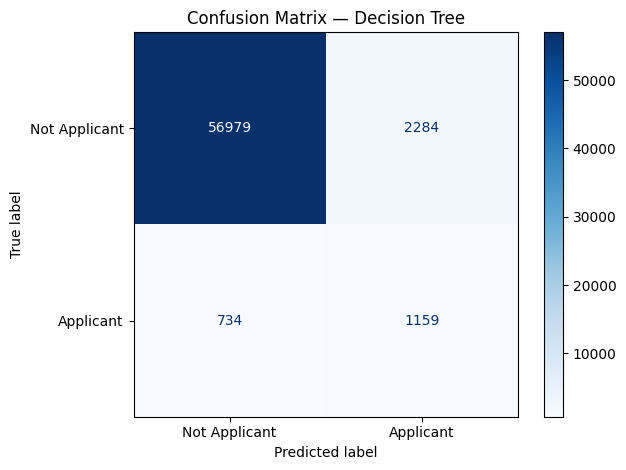

In [15]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict on test set
y_pred = dt_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc*100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Applicant', 'Applicant']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Applicant', 'Applicant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

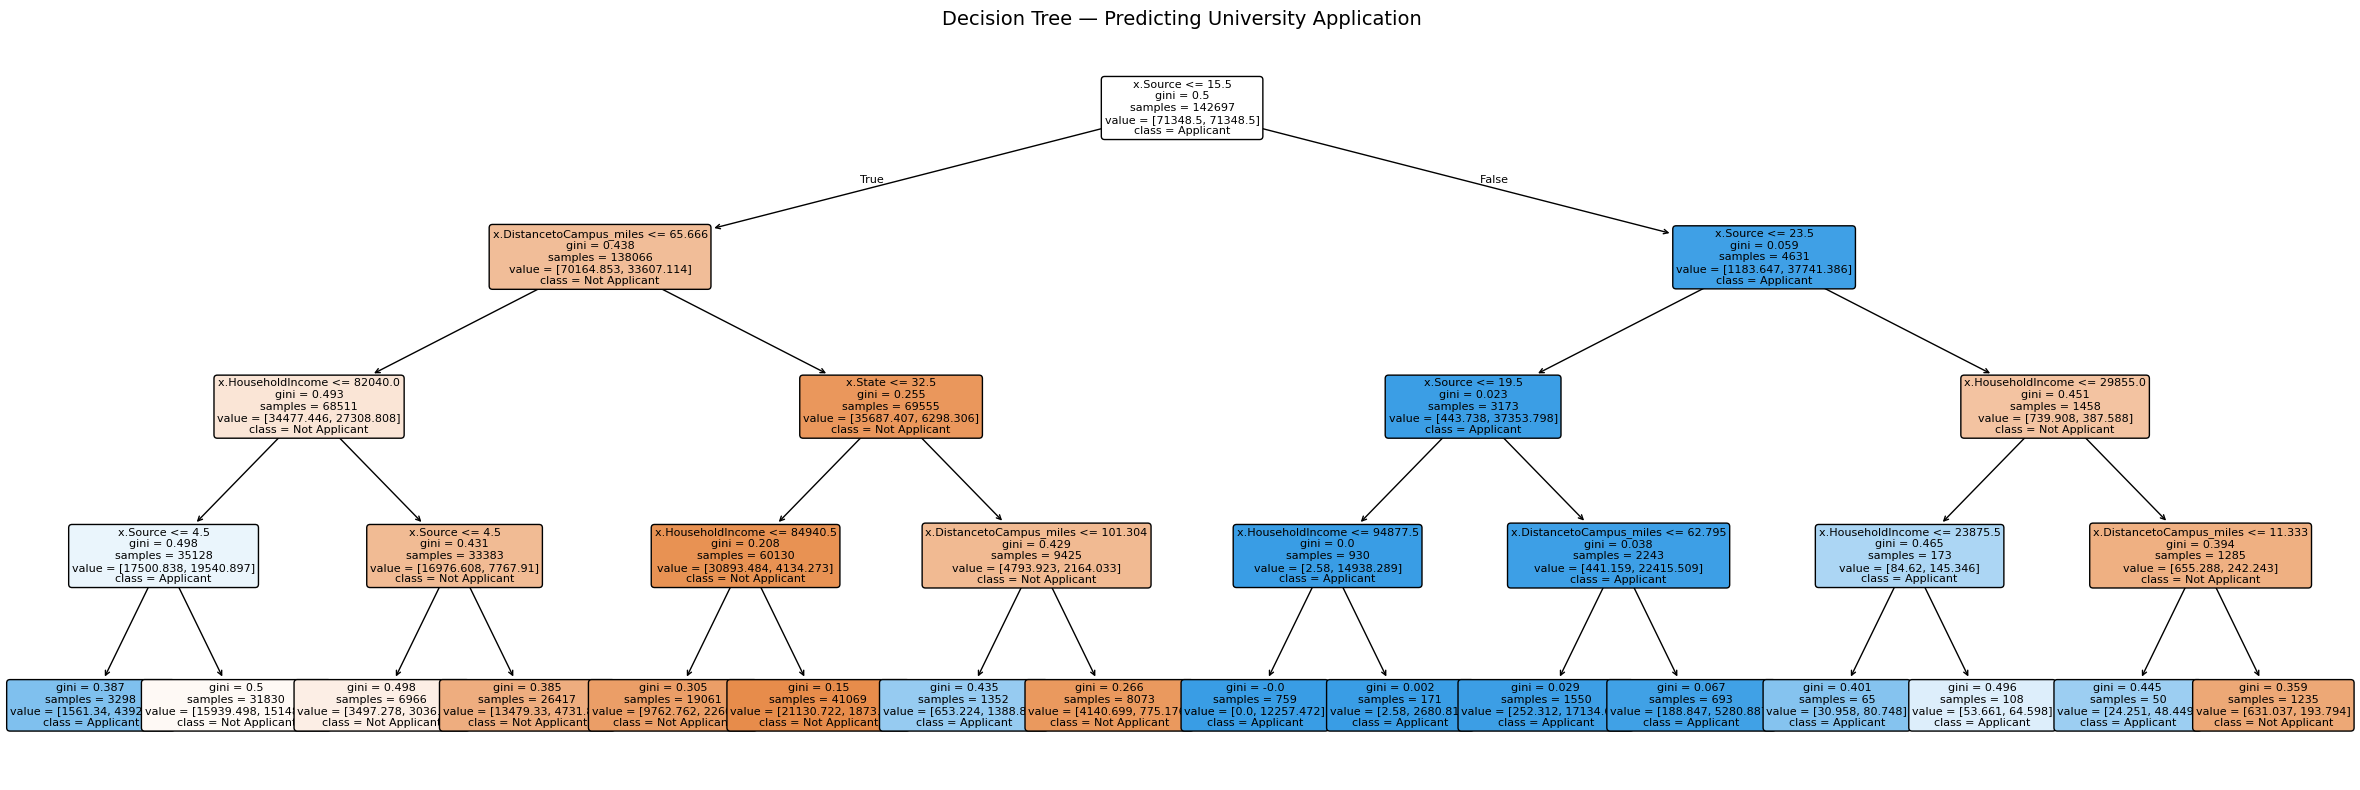

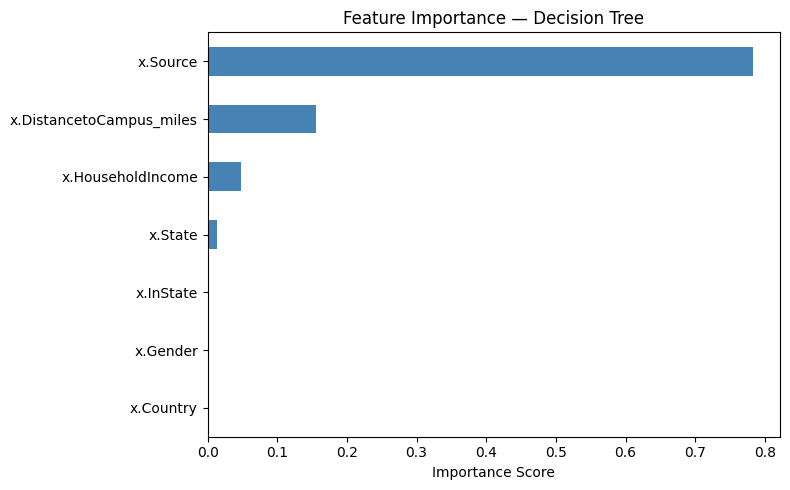

Feature importances:
x.Source                    0.782677
x.DistancetoCampus_miles    0.155535
x.HouseholdIncome           0.048544
x.State                     0.013244
x.Country                   0.000000
x.Gender                    0.000000
x.InState                   0.000000
dtype: float64


In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(24, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=['Not Applicant', 'Applicant'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree — Predicting University Application", fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

importances_sorted.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Feature importances:")
print(importances.sort_values(ascending=False))

**Analysis:**

The decision tree model reached an overall accuracy of 95.07%, which at first glance appears strong. However, this figure is misleading due to severe class imbalance  only 3.1% of the training data are actual applicants. The model's true performance on the minority class tells a more honest story: it correctly identified 61% of real applicants (recall), but only 34% of students it flagged as applicants actually were (precision). This means the model catches more than half of true applicants but generates a significant number of false positives along the way.

The feature importance chart reveals that the recruitment source (x.Source) is by far the most powerful predictor of application, accounting for 78.3% of the tree's splitting decisions. This tells me that where a student comes from  which channel or program introduced them to the university  is the single strongest signal of whether they will eventually apply. Distance to campus (15.6%) is the second most important feature, suggesting that proximity plays a meaningful role in a student's decision to follow through with an application. Household income contributes modestly at 4.9%, while state accounts for just 1.3%. Notably, gender, country, and in-state status contributed zero predictive value to the model.

The tree's depth of 4 with 16 leaves strikes a reasonable balance between interpretability and performance, avoiding the overfitting that would come with a deeper, more complex tree.

**4. Actionable Recommendations for the Marketing Department**

**Recommendations:**

Based on the decision tree model, I have three concrete recommendations for the marketing department.

First, the marketing team should double down on the highest-converting recruitment sources. Since x.Source accounts for 78.3% of the model's predictive power, not all recruitment channels are created equal. I recommend auditing which specific sources produce the most applicants and reallocating budget away from low-converting channels toward the ones that consistently move students from prospect to applicant. Investing in the wrong source is essentially wasted spend.

Second, the team should prioritize geographically close prospects. Distance to campus is the second strongest predictor at 15.6%, meaning students who live closer to campus are significantly more likely to apply. I recommend designing targeted local and regional campaigns such as campus visit invitations, open days, and community outreach specifically aimed at students within a reasonable commute radius. These students have a higher baseline probability of converting and should be nurtured accordingly.

Third, given that household income shows some predictive value (4.9%), the marketing team should consider developing tailored financial aid messaging for lower-income prospects. These students may be interested in applying but held back by perceived cost barriers. Proactively communicating scholarship and financial aid opportunities to this segment could meaningfully improve conversion rates.

Finally, I recommend the university invest in collecting cleaner and more complete data. Over 84% of SAT scores and 51% of GPA values were missing and had to be excluded from the model entirely. These academic performance indicators could be among the strongest predictors of application intent, and their absence likely limits the model's accuracy. Better data collection practices would allow future models to be significantly more precise.

## Problem 2: Bank Operations  Classification Tree

**2.1: Run a Classifier with 90:10, 80:20, and 70:30 Split Strategy**

In [17]:
import pandas as pd
import numpy as np

# Load dataset directly from GitHub
url = 'https://raw.githubusercontent.com/jcbonilla/BusinessAnalytics/master/BAData/bank_marketing.csv'
df_bank = pd.read_csv(url)

# Initial inspection
print("Shape:", df_bank.shape)
print("\nColumns:", df_bank.columns.tolist())
print("\nTarget variable distribution:")
print(df_bank['y'].value_counts())
print(df_bank['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print("\nMissing values:")
print(df_bank.isnull().sum())
print("\nFirst 5 rows:")
df_bank.head()

Shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target variable distribution:
y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.73%
yes    11.27%
Name: proportion, dtype: object

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Analysis:**

The bank marketing dataset contains 41,188 records across 21 features, with no missing values in any column  making preprocessing straightforward. The target variable `y` indicates whether a client subscribed to a term deposit, and the distribution reveals a significant class imbalance: 88.73% of clients said no while only 11.27% said yes. This imbalance is important to keep in mind when evaluating model accuracy, as a naive model that always predicts "no" would already achieve ~89% accuracy without learning anything meaningful. I will use `class_weight='balanced'` in the decision tree to address this.

**2.1: Preprocessing — Encode Categorical Variables**

In [18]:
from sklearn.preprocessing import LabelEncoder

df_bank_model = df_bank.copy()

# Encode all categorical columns using LabelEncoder
label_encoders_bank = {}
for col in df_bank_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_bank_model[col] = le.fit_transform(df_bank_model[col].astype(str))
    label_encoders_bank[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Confirm shape and no missing values
print(f"\nShape after encoding: {df_bank_model.shape}")
print(f"Missing values: {df_bank_model.isnull().sum().sum()}")
print("\nSample:")
print(df_bank_model.head(3))

Encoded 'job': {'admin.': np.int64(0), 'blue-collar': np.int64(1), 'entrepreneur': np.int64(2), 'housemaid': np.int64(3), 'management': np.int64(4), 'retired': np.int64(5), 'self-employed': np.int64(6), 'services': np.int64(7), 'student': np.int64(8), 'technician': np.int64(9), 'unemployed': np.int64(10), 'unknown': np.int64(11)}
Encoded 'marital': {'divorced': np.int64(0), 'married': np.int64(1), 'single': np.int64(2), 'unknown': np.int64(3)}
Encoded 'education': {'basic.4y': np.int64(0), 'basic.6y': np.int64(1), 'basic.9y': np.int64(2), 'high.school': np.int64(3), 'illiterate': np.int64(4), 'professional.course': np.int64(5), 'university.degree': np.int64(6), 'unknown': np.int64(7)}
Encoded 'default': {'no': np.int64(0), 'unknown': np.int64(1), 'yes': np.int64(2)}
Encoded 'housing': {'no': np.int64(0), 'unknown': np.int64(1), 'yes': np.int64(2)}
Encoded 'loan': {'no': np.int64(0), 'unknown': np.int64(1), 'yes': np.int64(2)}
Encoded 'contact': {'cellular': np.int64(0), 'telephone': np

**Analysis:**

All categorical variables have been successfully encoded into numeric format. The dataset remains clean with 41,188 rows and 21 columns and zero missing values after encoding no rows needed to be dropped. The target variable `y` is now binary: 0 for "no" and 1 for "yes". The data is ready for model training.

**2.1: Train Classification Trees with 90:10, 80:20, and 70:30 Splits**

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define features and target
X = df_bank_model.drop(columns=['y'])
y = df_bank_model['y']

# Define three split strategies
splits = {'90:10': 0.10, '80:20': 0.20, '70:30': 0.30}
models = {}
results = {}

for split_name, test_size in splits.items():
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Train decision tree
    dt = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42
    )
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)

    # Store results
    acc = accuracy_score(y_test, y_pred)
    models[split_name] = dt
    results[split_name] = {
        'accuracy': acc,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'train_size': X_train.shape[0],
        'test_size': X_test.shape[0]
    }

    print(f"--- Split {split_name} ---")
    print(f"  Training samples: {X_train.shape[0]}")
    print(f"  Test samples:     {X_test.shape[0]}")
    print(f"  Accuracy:         {acc*100:.2f}%")
    print(f"  Tree depth:       {dt.get_depth()}")
    print(f"  Leaves:           {dt.get_n_leaves()}")
    print()

--- Split 90:10 ---
  Training samples: 37069
  Test samples:     4119
  Accuracy:         78.85%
  Tree depth:       4
  Leaves:           16

--- Split 80:20 ---
  Training samples: 32950
  Test samples:     8238
  Accuracy:         80.23%
  Tree depth:       4
  Leaves:           16

--- Split 70:30 ---
  Training samples: 28831
  Test samples:     12357
  Accuracy:         79.38%
  Tree depth:       4
  Leaves:           16



--- Split 90:10 ---
              precision    recall  f1-score   support

          No       0.99      0.77      0.87      3655
         Yes       0.34      0.96      0.50       464

    accuracy                           0.79      4119
   macro avg       0.67      0.86      0.69      4119
weighted avg       0.92      0.79      0.82      4119

--- Split 80:20 ---
              precision    recall  f1-score   support

          No       0.99      0.78      0.88      7310
         Yes       0.36      0.96      0.52       928

    accuracy                           0.80      8238
   macro avg       0.68      0.87      0.70      8238
weighted avg       0.92      0.80      0.84      8238

--- Split 70:30 ---
              precision    recall  f1-score   support

          No       0.99      0.77      0.87     10965
         Yes       0.35      0.95      0.51      1392

    accuracy                           0.79     12357
   macro avg       0.67      0.86      0.69     12357
weighted avg  

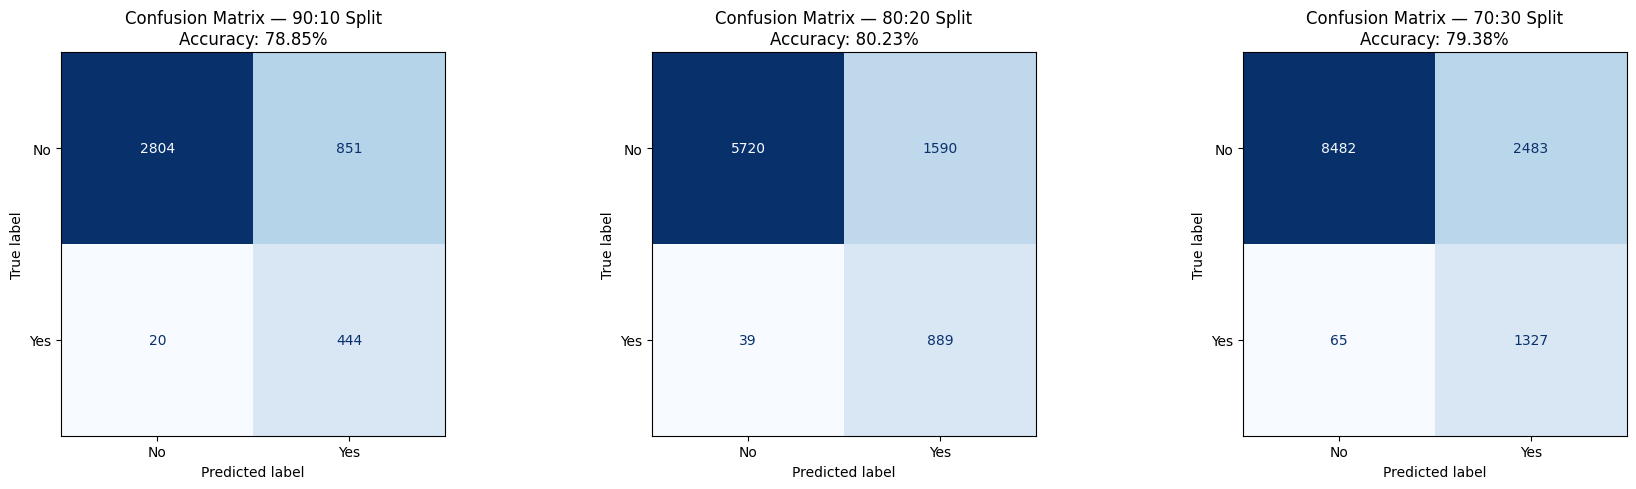

In [21]:
# Print classification reports and plot confusion matrices for all three splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, res) in zip(axes, results.items()):
    print(f"--- Split {split_name} ---")
    print(classification_report(res['y_test'], res['y_pred'],
                                 target_names=['No', 'Yes']))

    # Confusion matrix
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No', 'Yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix — {split_name} Split\nAccuracy: {res['accuracy']*100:.2f}%")

plt.tight_layout()
plt.show()

**Analysis:**

I trained three decision trees using 90:10, 80:20, and 70:30 train-test splits to predict whether a bank client would subscribe to a term deposit. All three models were built with a maximum depth of 4 and balanced class weights to account for the 88.73% vs 11.27% class imbalance in the data.

The overall accuracy across the three splits was very similar  78.85%, 80.23%, and 79.38% respectively  suggesting that the model's performance is stable regardless of how much data is used for training. However, raw accuracy is a misleading metric here given the class imbalance. A more telling picture comes from the precision and recall scores for the "Yes" class.

Across all three splits, the model achieved a recall of approximately 95-96% for the "Yes" class, meaning it correctly identified nearly all actual subscribers. However, precision for "Yes" was only around 34-36%, meaning a large proportion of clients flagged as likely subscribers were false positives. This trade-off is a direct result of using `class_weight='balanced'`, which intentionally sacrifices precision to capture more true positives  a reasonable choice when missing a real subscriber is more costly than contacting an uninterested one.

The confusion matrices confirm this pattern consistently: for example, in the 70:30 split, the model correctly flagged 1,327 out of 1,392 actual subscribers (95.3% recall) but also incorrectly flagged 2,483 non-subscribers as potential subscribers. The "No" class, by contrast, was predicted with 99% precision across all splits, reflecting how well the model handles the majority class.

**2.2: Interpret the Classification Trees and Describe Their Accuracy**

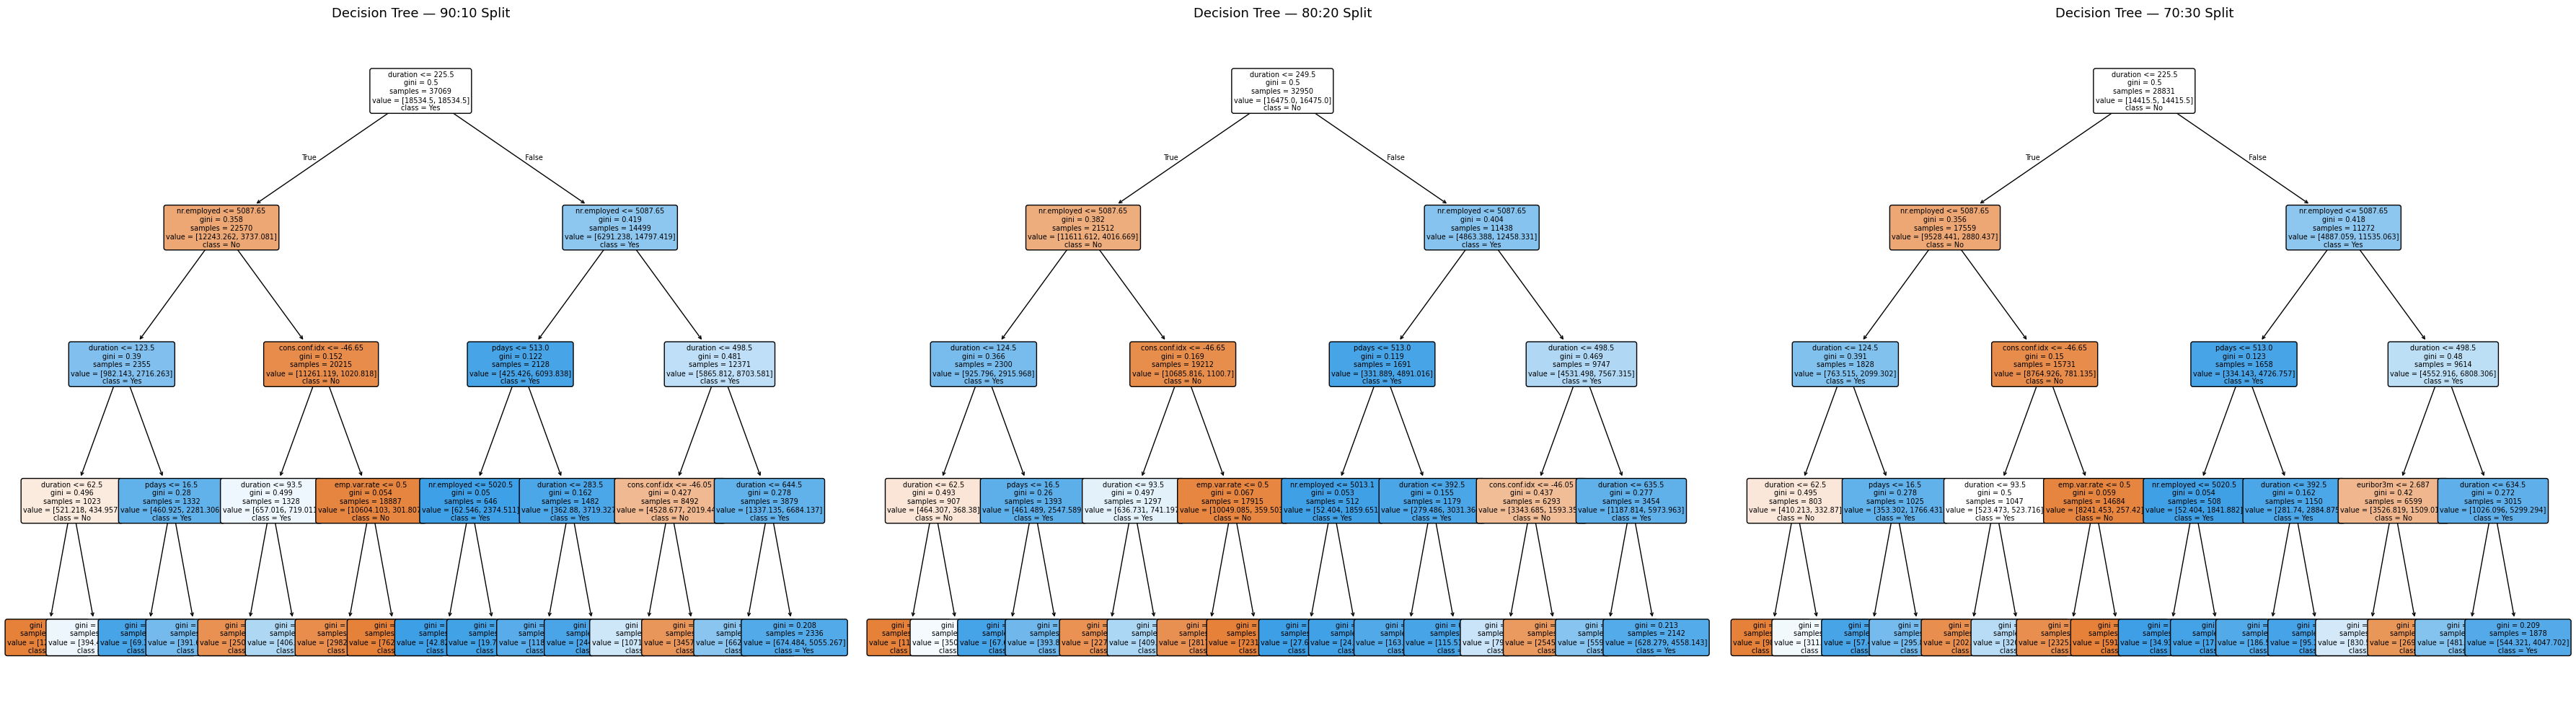

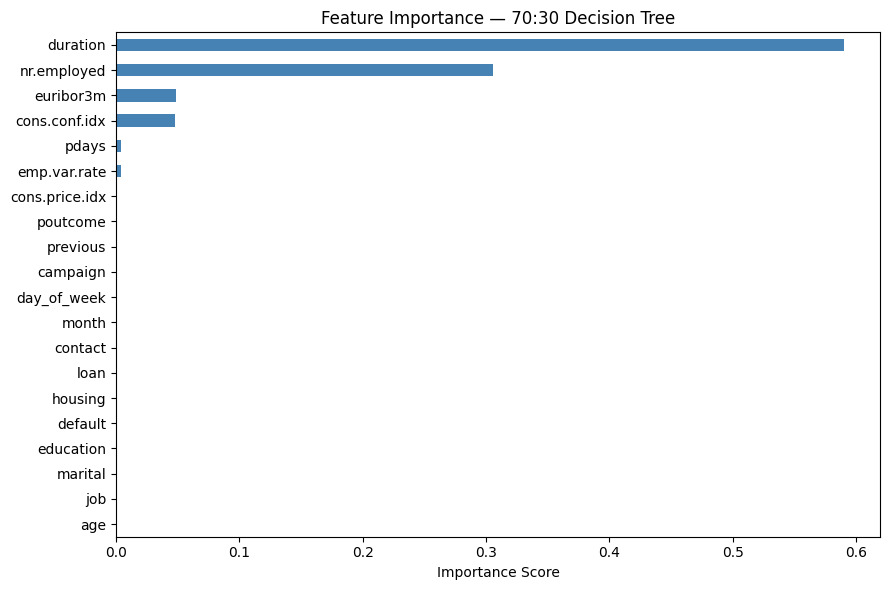

Feature importances (70:30 model):
duration          0.590019
nr.employed       0.305871
euribor3m         0.048738
cons.conf.idx     0.047428
pdays             0.004207
emp.var.rate      0.003737
job               0.000000
age               0.000000
education         0.000000
marital           0.000000
default           0.000000
housing           0.000000
previous          0.000000
campaign          0.000000
day_of_week       0.000000
month             0.000000
contact           0.000000
loan              0.000000
poutcome          0.000000
cons.price.idx    0.000000
dtype: float64


In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(36, 10))

for ax, (split_name, model) in zip(axes, models.items()):
    plot_tree(
        model,
        feature_names=X.columns.tolist(),
        class_names=['No', 'Yes'],
        filled=True,
        rounded=True,
        fontsize=7,
        ax=ax
    )
    ax.set_title(f"Decision Tree — {split_name} Split", fontsize=13)

plt.tight_layout()
plt.show()

# Feature importance (using 70:30 model as reference)
importances = pd.Series(
    models['70:30'].feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(9, 6), color='steelblue')
plt.title("Feature Importance — 70:30 Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Feature importances (70:30 model):")
print(importances.sort_values(ascending=False))

**Analysis:**

All three decision trees share identical structure  a depth of 4 with 16 leaves  confirming that the model architecture is stable across different split sizes. The feature importance chart from the 70:30 model tells a clear and consistent story about what drives subscription behavior.

Call duration is overwhelmingly the most important predictor, accounting for 59% of the tree's splitting decisions. This makes intuitive sense: a client who stays on the phone longer is almost certainly more engaged and more likely to subscribe. The number of employees (`nr.employed`) is the second most important feature at 30.6%, acting as a macroeconomic signal  when the bank has fewer employees, it likely coincides with periods of economic tightening where clients may be more inclined to seek stable financial products like term deposits. The Euribor 3-month rate (4.9%) and consumer confidence index (4.7%) contribute modestly, reflecting broader economic conditions that influence financial decision-making. All remaining features  including age, job, marital status, education, and contact method  contributed zero predictive value to the model.

In terms of accuracy, all three splits produced nearly identical results: 78.85% (90:10), 80.23% (80:20), and 79.38% (70:30). The consistency across splits indicates that the model is not sensitive to training size within this range and that the learned patterns generalize well. The 80:20 split produced the marginally highest accuracy at 80.23%, though the differences are small enough to be practically insignificant.

**2.3: Which Model Would You Recommend and Why?**

In [23]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

# Build a comparison table across all three splits
comparison = []

for split_name, res in results.items():
    comparison.append({
        'Split': split_name,
        'Train Samples': res['train_size'],
        'Test Samples': res['test_size'],
        'Accuracy (%)': round(res['accuracy'] * 100, 2),
        'Precision - Yes': round(precision_score(res['y_test'], res['y_pred']), 2),
        'Recall - Yes': round(recall_score(res['y_test'], res['y_pred']), 2),
        'F1 - Yes': round(f1_score(res['y_test'], res['y_pred']), 2)
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

Split  Train Samples  Test Samples  Accuracy (%)  Precision - Yes  Recall - Yes  F1 - Yes
90:10          37069          4119         78.85             0.34          0.96      0.50
80:20          32950          8238         80.23             0.36          0.96      0.52
70:30          28831         12357         79.38             0.35          0.95      0.51


**Analysis:**

I would recommend the **80:20 split model** as the best choice among the three.

The comparison table shows that all three models are remarkably consistent  accuracy ranges narrowly between 78.85% and 80.23%, recall for the "Yes" class is 95-96% across the board, and F1 scores differ by at most 0.02. This consistency confirms that the model has learned stable patterns from the data regardless of split size. Given that the differences are small, the recommendation comes down to which split offers the best balance between training reliability and evaluation robustness.

The 90:10 split uses the most training data (37,069 samples) but evaluates on only 4,119 test samples, which makes the accuracy estimate less statistically reliable  a small test set is more susceptible to variance. The 70:30 split evaluates on the largest test set (12,357 samples) and produces stable estimates, but it trains on the fewest samples (28,831), slightly l

## Problem 3: Car Evaluation Data — Classification Tree

**3.1: Load, Inspect, and Predict Car Acceptance with 80:20 Split**

In [26]:
import pandas as pd
import numpy as np

# Load dataset directly from GitHub
url = 'https://raw.githubusercontent.com/jcbonilla/BusinessAnalytics/master/BAData/car-data.csv'
df_car = pd.read_csv(url)

# Initial inspection
print("Shape:", df_car.shape)
print("\nColumns:", df_car.columns.tolist())
print("\nFirst 5 rows:")
print(df_car.head())
print("\nMissing values:")
print(df_car.isnull().sum())
print("\nUnique values per column:")
for col in df_car.columns:
    print(f"  {col}: {df_car[col].unique()}")

Shape: (1727, 7)

Columns: ['Car-Price', 'Main. Price', 'Doors', 'Persons', 'Boot Space', 'Safety', 'Car Acceptability']

First 5 rows:
  Car-Price Main. Price  Doors  Persons  Boot Space  Safety Car Acceptability
0     vhigh       vhigh      2        2          -1       0             unacc
1     vhigh       vhigh      2        2          -1       1             unacc
2     vhigh       vhigh      2        2           0      -1             unacc
3     vhigh       vhigh      2        2           0       0             unacc
4     vhigh       vhigh      2        2           0       1             unacc

Missing values:
Car-Price            0
Main. Price          0
Doors                0
Persons              0
Boot Space           0
Safety               0
Car Acceptability    0
dtype: int64

Unique values per column:
  Car-Price: ['vhigh' 'high' 'med' 'low']
  Main. Price: ['vhigh' 'high' 'med' 'low']
  Doors: [2 3 4]
  Persons: [2 4 6]
  Boot Space: [-1  0  1]
  Safety: [ 0  1 -1]
  Car Acce

**Analysis:**

The car evaluation dataset contains 1,727 records across 7 columns  6 input features and 1 target variable (`Car Acceptability`). There are no missing values, making the dataset clean and ready for modeling. The features include both categorical variables (car price, maintenance price

**Question 3.2: Create 80:20 split and validate your model using the accuracy metric (ratio of
correct predictions vs total predictions).**

Encoded 'Car-Price': {'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2), 'vhigh': np.int64(3)}
Encoded 'Main. Price': {'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2), 'vhigh': np.int64(3)}
Encoded 'Car Acceptability': {'good': np.int64(0), 'unacc': np.int64(1)}

Shape after encoding: (1727, 7)

Target distribution:
Car Acceptability
1    1209
0     518
Name: count, dtype: int64
Car Acceptability
1    70.01%
0    29.99%
Name: proportion, dtype: object

Training samples: 1381
Test samples:     346

Overall Accuracy: 87.57%

Classification Report:
              precision    recall  f1-score   support

        good       0.71      1.00      0.83       104
       unacc       1.00      0.82      0.90       242

    accuracy                           0.88       346
   macro avg       0.85      0.91      0.87       346
weighted avg       0.91      0.88      0.88       346



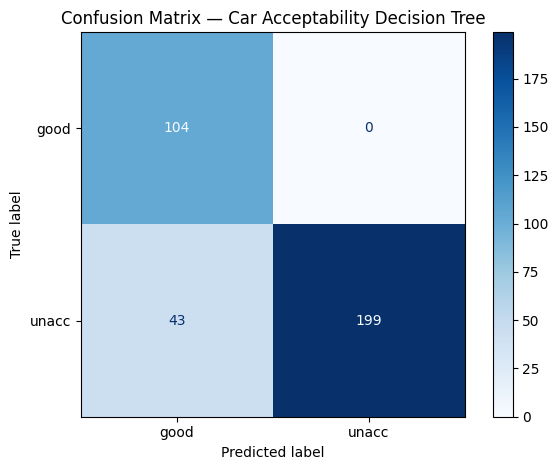

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

df_car_model = df_car.copy()

# Encode categorical columns
label_encoders_car = {}
cat_cols = ['Car-Price', 'Main. Price', 'Car Acceptability']
for col in cat_cols:
    le = LabelEncoder()
    df_car_model[col] = le.fit_transform(df_car_model[col].astype(str))
    label_encoders_car[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nShape after encoding: {df_car_model.shape}")

# Define features and target
X_car = df_car_model.drop(columns=['Car Acceptability'])
y_car = df_car_model['Car Acceptability']

print(f"\nTarget distribution:")
print(y_car.value_counts())
print(y_car.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# 80:20 split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_car, y_car, test_size=0.20, random_state=42, stratify=y_car
)

print(f"\nTraining samples: {X_train_c.shape[0]}")
print(f"Test samples:     {X_test_c.shape[0]}")

# Train decision tree
dt_car = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
dt_car.fit(X_train_c, y_train_c)
y_pred_c = dt_car.predict(X_test_c)

# Evaluate
acc_car = accuracy_score(y_test_c, y_pred_c)
print(f"\nOverall Accuracy: {acc_car*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c,
      target_names=label_encoders_car['Car Acceptability'].classes_))

# Confusion matrix
cm_car = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_car,
                               display_labels=label_encoders_car['Car Acceptability'].classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Car Acceptability Decision Tree")
plt.tight_layout()
plt.show()

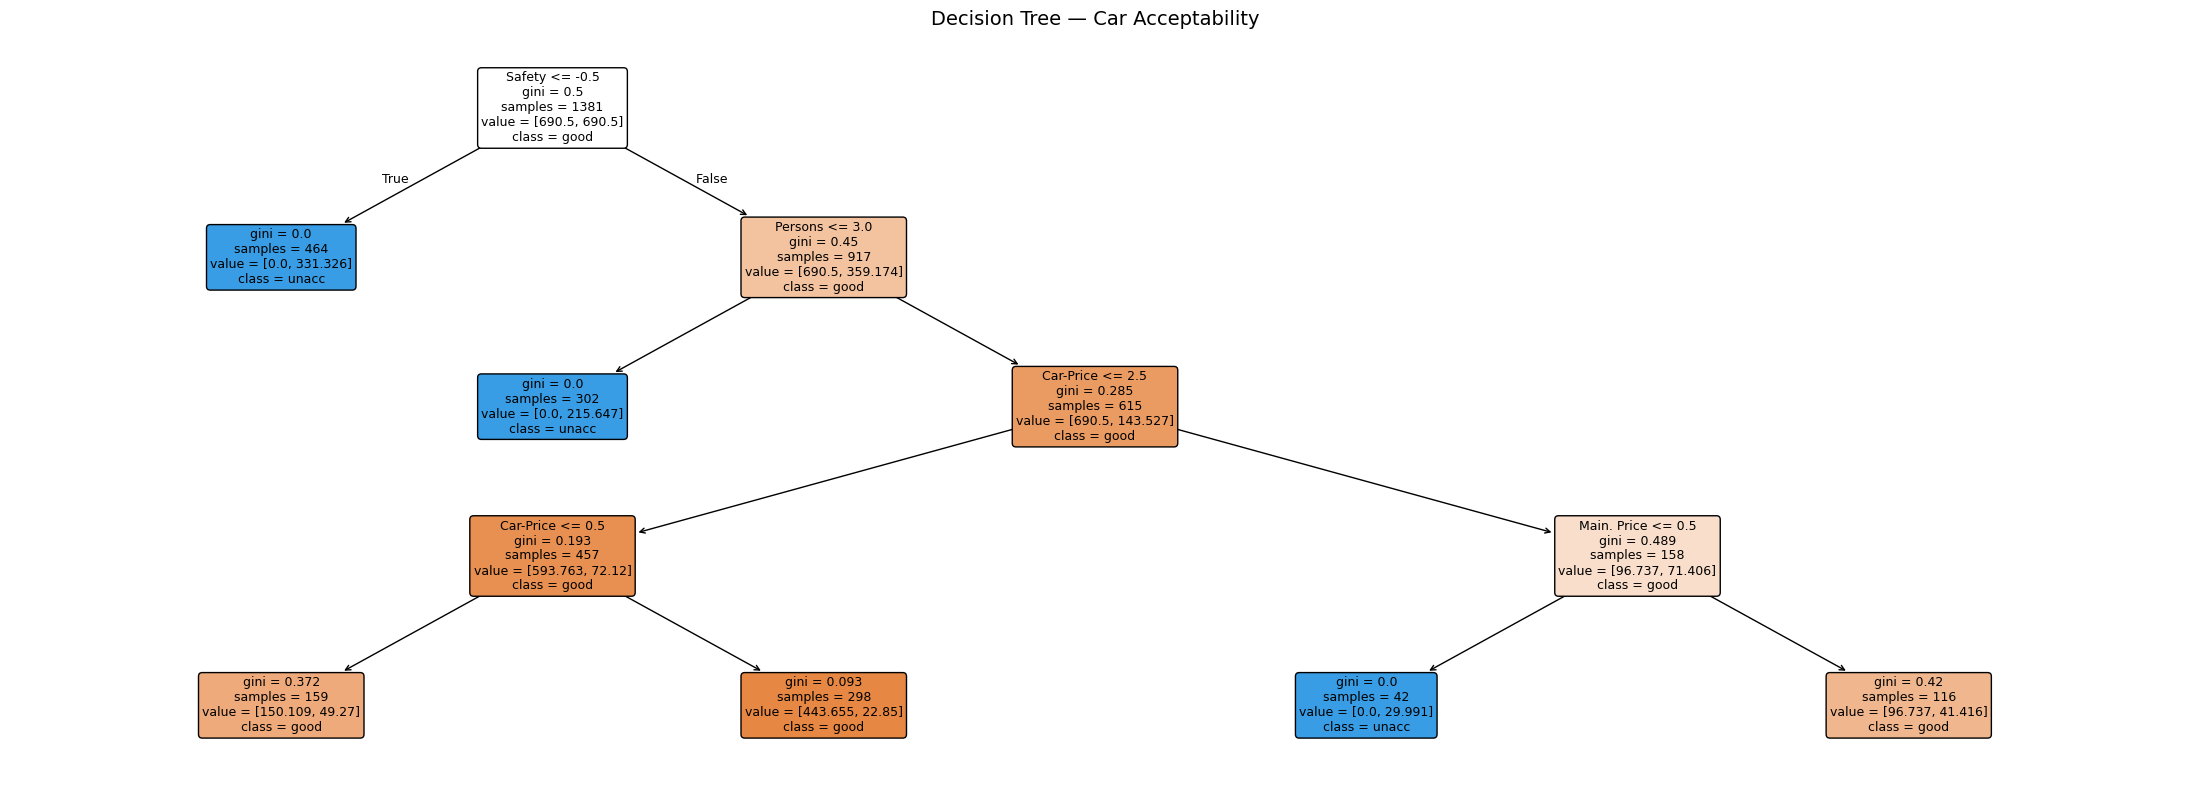

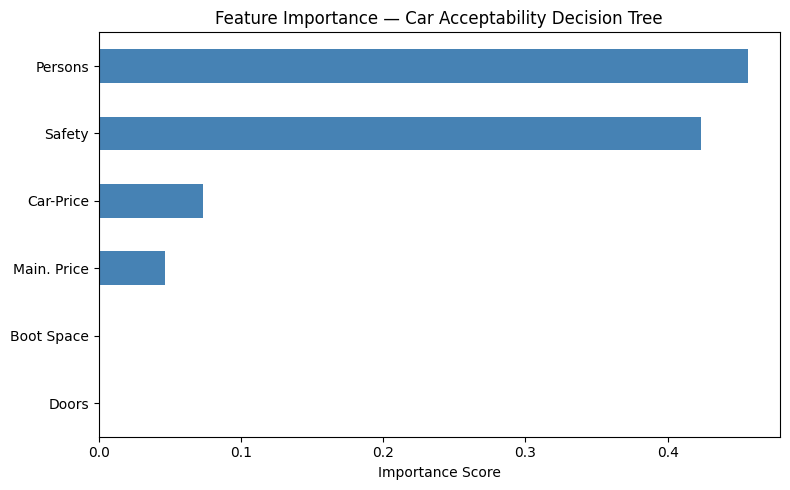

Feature importances:
Persons        0.456234
Safety         0.423335
Car-Price      0.073498
Main. Price    0.046933
Boot Space     0.000000
Doors          0.000000
dtype: float64


In [28]:
from sklearn.tree import plot_tree
import pandas as pd
import matplotlib.pyplot as plt

# Visualize the decision tree
plt.figure(figsize=(22, 8))
plot_tree(
    dt_car,
    feature_names=X_car.columns.tolist(),
    class_names=label_encoders_car['Car Acceptability'].classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree — Car Acceptability", fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance
importances_car = pd.Series(
    dt_car.feature_importances_,
    index=X_car.columns
).sort_values(ascending=True)

importances_car.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Feature Importance — Car Acceptability Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Feature importances:")
print(importances_car.sort_values(ascending=False))

**Analysis:**

I built a classification decision tree with an 80:20 split to predict whether a car would be accepted or not. The dataset contains 1,727 records with no missing values, and the target variable is moderately imbalanced  70% unacceptable and 30% good. The model achieved an overall accuracy of 87.57% on the test set of 346 samples, which is a strong result.

The classification report reveals an important asymmetry: the model perfectly identified every "good" car in the test set (100% recall for "good"), meaning it never missed an acceptable car. For the "unacc" class, recall was 82%, with 43 unacceptable cars incorrectly predicted as good. This trade-off is acceptable given that the cost of overlooking a good car is generally higher than the cost of over-flagging an unacceptable one.

The decision tree and feature importance chart together tell a clear story about what drives acceptance. Person capacity is the single most important feature at 45.6%, meaning cars that can only seat 2 people are systematically rejected first. Safety follows closely at 42.3%, confirmed by the tree's first split  any car below the acceptable safety threshold is immediately classified as unacceptable regardless of any other attribute. Together, these two features account for nearly 88% of the model's predictive power. Car purchase price contributes 7.3% and maintenance price 4.7%, reflecting that cost

**3.3: Using your acceptance results from the model, how would you suggest a strategy
for cars in a used car seller lot. What types of cars should they have, what should
be the compensation of the fleet?**

In [30]:
# Use the model to predict acceptance on the FULL dataset
df_car_full = df_car.copy()

# Apply same encoding
for col, le in label_encoders_car.items():
    df_car_full[col] = le.transform(df_car_full[col].astype(str))

X_full = df_car_full.drop(columns=['Car Acceptability'])
df_car_full['predicted'] = dt_car.predict(X_full)

# Filter to only model-predicted accepted cars (good = 0)
accepted = df_car_full[df_car_full['predicted'] == 0].copy()

print(f"Total cars: {len(df_car_full)}")
print(f"Predicted accepted (good): {len(accepted)} ({len(accepted)/len(df_car_full)*100:.1f}%)")
print(f"Predicted unacceptable: {len(df_car_full) - len(accepted)}")

# Decode back to original labels for readability
for col, le in label_encoders_car.items():
    accepted[col] = le.inverse_transform(accepted[col])
    df_car_full[col] = le.inverse_transform(df_car_full[col])

# Profile of accepted cars
print("\n--- Accepted Cars Profile ---")
for col in ['Car-Price', 'Main. Price', 'Doors', 'Persons', 'Boot Space', 'Safety']:
    print(f"\n{col}:")
    counts = accepted[col].value_counts()
    pcts = accepted[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Pct (%)': pcts}))

Total cars: 1727
Predicted accepted (good): 720 (41.7%)
Predicted unacceptable: 1007

--- Accepted Cars Profile ---

Car-Price:
           Count  Pct (%)
Car-Price                
high         192     26.7
med          192     26.7
low          192     26.7
vhigh        144     20.0

Main. Price:
             Count  Pct (%)
Main. Price                
vhigh          192     26.7
med            192     26.7
low            192     26.7
high           144     20.0

Doors:
       Count  Pct (%)
Doors                
4        360     50.0
2        180     25.0
3        180     25.0

Persons:
         Count  Pct (%)
Persons                
4          360     50.0
6          360     50.0

Boot Space:
            Count  Pct (%)
Boot Space                
-1            240     33.3
 0            240     33.3
 1            240     33.3

Safety:
        Count  Pct (%)
Safety                
0         360     50.0
1         360     50.0


**Recommendations:**

The model predicted 720 out of 1,727 cars (41.7%) as acceptable. Analyzing the profile of these accepted cars reveals clear patterns that should directly inform a used car seller's inventory strategy.

On pricing, the accepted fleet is broadly distributed across all price tiers  high, medium, and low each account for 26.7% of accepted cars, with very high price making up the remaining 20%. This tells me that price alone does not disqualify a car, and the seller does not need to avoid expensive vehicles entirely. However, since very high priced cars represent the smallest share of accepted inventory, I would recommend keeping them as a minority of the lot roughly 20%  while building the bulk of inventory around medium and low priced vehicles that have the widest buyer appeal.

On maintenance cost, the distribution is similarly even across tiers, with very high, medium, and low maintenance each at 26.7% and high at 20%. This mirrors the price finding: maintenance cost is not a dealbreaker on its own, but very high maintenance vehicles should again be kept at around 20% of the fleet to reflect their lower share among accepted cars.

Passenger capacity is the most decisive structural requirement. Every single accepted car in the model seats either 4 or 6 people, split evenly at 50% each. No 2-seat car was predicted as acceptable. This is the clearest directive from the model: the seller should stock exclusively 4-plus seat vehicles and avoid 2-seaters entirely.

On doors, 4-door cars dominate accepted inventory at 50%, with 2-door and 3-door models each at 25%. I recommend that half the fleet be 4-door vehicles, with the remainder split between 2 and 3-door options. Boot space and safety were evenly distributed across all categories among accepted cars, meaning the model does not favor any specific tier for these features  the seller can stock freely across boot sizes and safety ratings without it affecting acceptance likelihood.

In summary, the optimal fleet composition for a used car seller should consist entirely of cars seating 4 or more passengers, with 4-door models making up half the lot, pricing and maintenance spread across low to high tiers with very high cost vehicles capped at around 20%, and no restrictions needed on boot space or safety rating.